# Data Analysis: WORC Job Data Cayman Islands

**Exploratory analysis of the job listing dataset provided by WORC in the Cayman Islands.** 
1. Bar chart of the annual salaries by industry 
2. Box plots of the data distributions of the highest paying industries 
3. Regression of years of education and annual salary

In [ ]:
import requests
import pandas as pd 
import matplotlib.pyplot as plt

## Example of using requests and pandas with the API

In [2]:
# requests allows users to obtain the data from the API via HTTP
# pandas allows the users to interact with this data for analysis, transformation, visualization, etc.

try:
    r = requests.get("http://127.0.0.1:8000/test")
    r.raise_for_status()
    
    data = r.json()

    df = pd.DataFrame(data)
    print(df)
except requests.HTTPError as e:
    print(f"HTTP error occured: {e}")
except Exception as e:
    print(f"Request failed: {e}")

   id job_post_id                               job_title  cig_sagc  \
0   1      B4Y3V7  Senior Banking Services Administrator      False   
1   2      C2K4R5                  Senior Account Manager     False   
2   3      D4H4V4               Insolvency Senior Manager     False   
3   4      E3G6B8      Assistant Manager – Personal Lines     False   
4   5      E4G4A7                      Insolvency Manager     False   

   employer_id  location_id  occupation_id  sub_industry_id  industry_id  \
0         2766            2            315               46            5   
1          785           11             33               32           16   
2          788            5             33               46            5   
3         2363            5            176               46            5   
4          788            5             33               46            5   

   status  ... years_experience_id hours_per_week currency  salary_frequency  \
0  Closed  ...                   7  

# TODO: request from jobs route with employers hashed and example query parameters, output to csv

## Bar Chart of Annual Pay by Industry

In [5]:
# obtain the job data for the entire data set then visualize the salaries by industry
try:
    r = requests.get("http://127.0.0.1:8000/jobs")
    r.raise_for_status()

    data = r.json()

    df = pd.DataFrame(data)

    industry_averages = df.groupby("industry")["mean_annual_salary"].mean()
    sorted_industry_averages = industry_averages.sort_values(ascending=False)
    # apply method used to add formatting to each result
    print(sorted_industry_averages.apply(lambda x: f"${x:,.2f}"))
except requests.HTTPError as e:
    print(f"HTTP error occurred: {e}")
except Exception as e:
    print("Unexpected error occured: {e}")


industry
Financial and Insurance Activities                                                                                            $92,707.86
Professional, Scientfic and Technical Activities                                                                              $80,364.99
Public Administration and Defence; Complulsory Social Security                                                                $80,010.00
Electricity, Gas, Steam, and Air Conditioning Supply                                                                          $69,041.24
Information and Communication                                                                                                 $62,670.00
Human Health and Social Work Activities                                                                                       $55,807.79
Education                                                                                                                     $49,182.24
Water Supply; Sewerage, Waste Ma

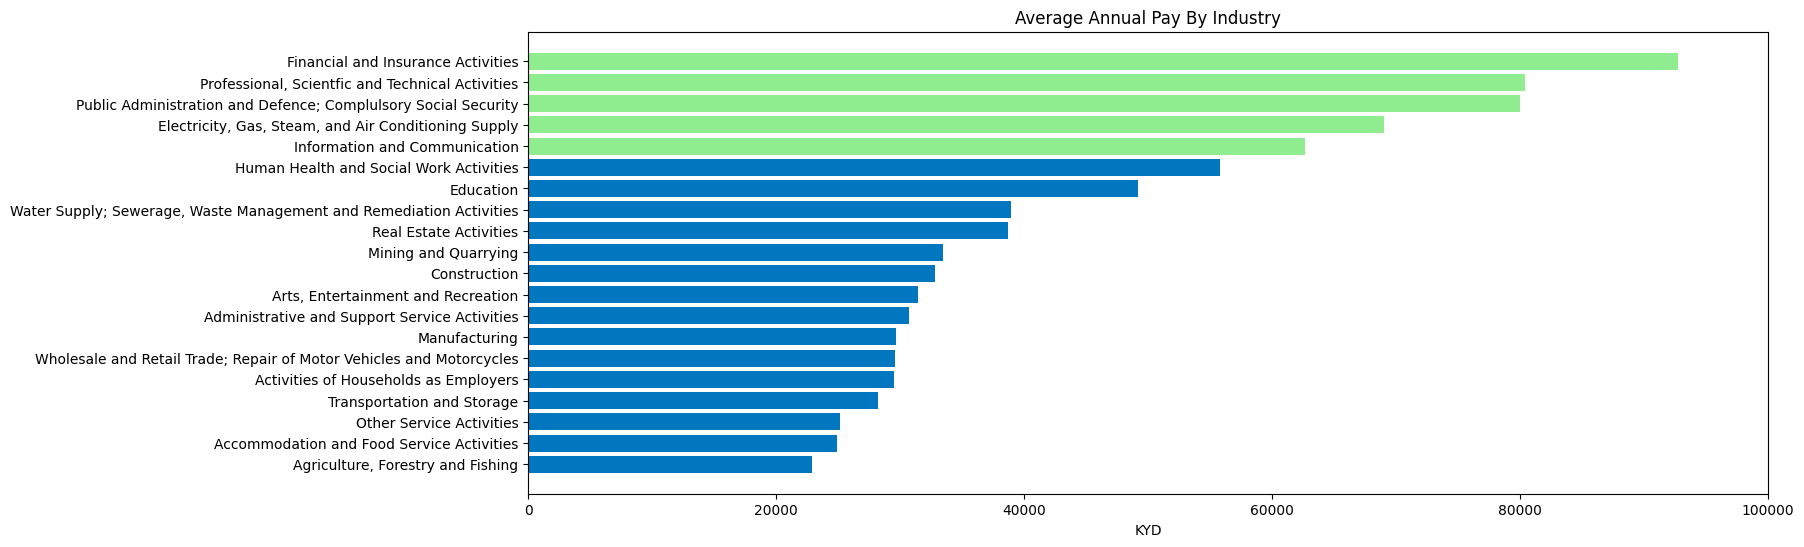

In [48]:
# Bar chart of the pay by industry
staging_df = pd.DataFrame(sorted_industry_averages)
sorted_df = staging_df.reset_index()
# Shorten excessivelly long name for label formatting
sorted_df["industry"] = sorted_df["industry"].apply(
    lambda val: "Activities of Households as Employers"
    if val.startswith("Activities") else val
)
# rank for coloring 
sorted_df["rank"] = sorted_df["mean_annual_salary"].rank(ascending=False)

# ranking added for coloring range - top five industries light green, all others light blue
sorted_df["colors"] = sorted_df["rank"].apply(
    lambda val: (.56, .93, .56) # light green
    if val <= 5 else (0, .467, .745) # light blue
)

# horizontal bar chart to show the average pay by industry
plt.figure(figsize=(16,6))
plt.title("Average Annual Pay By Industry")
plt.xlabel("KYD")
plt.barh(sorted_df["industry"], sorted_df["mean_annual_salary"], color=sorted_df["colors"]) # long lables therefore horizontal bar chart for readability
plt.xlim(0, 100000)
plt.gca().invert_yaxis() # greatest values shown at top
plt.show()
